# CA allegation types: matched vs. unmatched C Cases

**Question.** Among CA charges (C Cases), do the **§8(a) allegation types** differ between cases we
*could* link to an RC organizing petition and cases we could not?

**Why this is substantive, not just descriptive.** The five 8(a) clauses mean different things:

| clause | §8(a) of the NLRA — unfair labor practice by an employer |
|---|---|
| **8(a)(1)** | interfering with / coercing employees exercising their rights (the catch-all; rides along with most charges) |
| **8(a)(2)** | dominating or supporting a company union |
| **8(a)(3)** | discrimination (e.g. firing) to discourage union activity |
| **8(a)(4)** | retaliation for filing charges / testifying |
| **8(a)(5)** | **refusing to bargain collectively** — this presupposes an *already-recognised* union |

A match means a CA charge fell inside an RC petition's window — i.e. it coincides with a **fresh
organizing drive**, before a union is recognised. So we expect:

- **8(a)(3)** (retaliatory firing) and **8(a)(1)** (coercion) to be **over-represented** among matched
  cases — these are the classic during-campaign employer ULPs;
- **8(a)(5)** (refusal to bargain) to be **under-represented** among matched cases — a refusal-to-bargain
  charge implies an existing bargaining relationship, which is the *opposite* of a new petition.

If the data shows that pattern, it corroborates that the low overall CA match rate is largely
*substantive* (a big slice of CA charges are existing-union disputes that simply have no concurrent
RC petition to match), not a failure of the matcher.

**Allegation format.** The `allegations` cell is comma-separated tokens; a single token such as
`8(a)(1)(3)(5)` bundles clauses 1, 3 and 5. We parse every `(digit)` inside each `8(a)` token and
ignore the handful of stray `8(b)` co-charges.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA = Path("..")
assert (DATA / "merged_C_CASES_final.parquet").exists(), "Run from allegation_analysis/"

METHODS = {
    "fuzzy":   DATA / "rc_ac_matches.parquet",
    "cluster": DATA / "rc_ac_cluster_matches_20260517.parquet",
}
PRIMARY = "fuzzy"          # method used for the headline matched/unmatched split
CLAUSES = ["1", "2", "3", "4", "5"]
CLAUSE_LABEL = {c: f"8(a)({c})" for c in CLAUSES}


## 1. Load CA cases and parse the 8(a) allegation clauses

One row per CA case. `clauses` is the set of 8(a) sub-clauses present in the cell; we then make a 0/1 indicator column per clause. We only read clause digits from tokens that start with `8(a)` so the rare `8(b)` co-charge can't inflate the counts.

In [2]:
c_final = pd.read_parquet(DATA / "merged_C_CASES_final.parquet")
ca = c_final[c_final["type"] == "CA"].copy()
ca = ca.rename(columns={"case_number": "c_case_number"})

_clause_re = re.compile(r"\((\d)\)")
def parse_8a(cell):
    """Return the set of 8(a) clause digits ('1'..'5') present in an allegations cell."""
    if not isinstance(cell, str):
        return frozenset()
    out = set()
    for tok in cell.split(","):
        tok = tok.strip()
        if tok.startswith("8(a)"):
            out.update(d for d in _clause_re.findall(tok) if d in {"1", "2", "3", "4", "5"})
    return frozenset(out)

ca["clauses"] = ca["allegations"].apply(parse_8a)
ca["n_clauses"] = ca["clauses"].apply(len)
for c in CLAUSES:
    ca[CLAUSE_LABEL[c]] = ca["clauses"].apply(lambda s, c=c: c in s).astype(int)

ca["has_any_8a"] = ca["n_clauses"] > 0
print(f"CA cases:                         {len(ca):,}")
print(f"  with a parseable 8(a) clause:   {ca['has_any_8a'].sum():,} "
      f"({100*ca['has_any_8a'].mean():.1f}%)")
print(f"  allegations cell missing/empty: {(~ca['has_any_8a']).sum():,}")
print("\nOverall clause prevalence (% of all CA cases containing the clause):")
print((100 * ca[[CLAUSE_LABEL[c] for c in CLAUSES]].mean()).round(1).to_string())


CA cases:                         771,459
  with a parseable 8(a) clause:   770,830 (99.9%)
  allegations cell missing/empty: 629

Overall clause prevalence (% of all CA cases containing the clause):
8(a)(1)    71.0
8(a)(2)     2.8
8(a)(3)    45.0
8(a)(4)     4.3
8(a)(5)    45.9


## 2. Flag which CA cases were matched

A CA case is **matched** if its `c_case_number` appears in a method's RC↔CA output (i.e. it linked to ≥1 RC petition). We record both methods and use the primary method for the headline split.

In [3]:
for name, path in METHODS.items():
    matched_ids = set(pd.read_parquet(path, columns=["c_case_number"])["c_case_number"])
    ca[f"matched_{name}"] = ca["c_case_number"].isin(matched_ids)
    print(f"{name:>8s}: {ca[f'matched_{name}'].sum():,} CA cases matched "
          f"({100*ca[f'matched_{name}'].mean():.1f}% of CA)")

ca["matched"] = ca[f"matched_{PRIMARY}"]      # headline split uses PRIMARY


   fuzzy: 45,824 CA cases matched (5.9% of CA)
 cluster: 54,697 CA cases matched (7.1% of CA)


## 3. Reconstruct matching eligibility (for a fair second cut)

A CA case with no usable company/state/city (or flagged as a union/over-long name) can **never** match, for data reasons rather than substance. Those cases sit in 'unmatched' and could distort the comparison, so we rebuild the matcher's eligibility filter and later repeat the analysis on eligible cases only.

In [4]:
c_addr = pd.read_parquet(DATA / "merged_C_CASES_ADDRESS_with_union_flag.parquet")
c_addr = c_addr.rename(columns={"case_number": "c_case_number"}).drop_duplicates("c_case_number")

def _norm(s):
    s = s.fillna("").astype(str).str.lower().str.strip()
    for ch in [".", ",", "'", '"']:
        s = s.str.replace(ch, "", regex=False)
    return s.str.replace(r"\s+", " ", regex=True)

flagged = c_addr["is_union_name"].fillna(False) | c_addr["is_long_name"].fillna(False)
c_addr["eligible"] = ((~flagged)
                      & (_norm(c_addr["company_name"]) != "")
                      & (_norm(c_addr["state"]) != "")
                      & (_norm(c_addr["city"]) != ""))
ca = ca.merge(c_addr[["c_case_number", "eligible"]], on="c_case_number", how="left")
ca["eligible"] = ca["eligible"].fillna(False)
print(f"Eligible CA cases: {ca['eligible'].sum():,} ({100*ca['eligible'].mean():.1f}%)")


Eligible CA cases: 754,053 (97.7%)


## 4. Clause prevalence: matched vs. unmatched

For each clause we report the share of cases in each group that contain it, the difference in percentage points, and the **risk ratio** (matched prevalence ÷ unmatched prevalence). RR > 1 = over-represented among matched; RR < 1 = under-represented.

In [5]:
def prevalence_table(df, group_col="matched"):
    g = df.groupby(group_col)
    n = g.size().rename("n_cases")
    rows = []
    for c in CLAUSES:
        col = CLAUSE_LABEL[c]
        prev = 100 * g[col].mean()
        rows.append({"clause": col,
                     "matched_%":   prev.get(True, np.nan),
                     "unmatched_%": prev.get(False, np.nan)})
    t = pd.DataFrame(rows)
    t["diff_pp"] = (t["matched_%"] - t["unmatched_%"]).round(1)
    t["risk_ratio"] = (t["matched_%"] / t["unmatched_%"]).round(2)
    t["matched_%"] = t["matched_%"].round(1)
    t["unmatched_%"] = t["unmatched_%"].round(1)
    return t, n

print(f"Primary method: {PRIMARY}\n")
tbl_all, n_all = prevalence_table(ca)
print("Group sizes:", n_all.to_dict())
display(tbl_all)


Primary method: fuzzy

Group sizes: {False: 725635, True: 45824}


,clause,matched_%,unmatched_%,diff_pp,risk_ratio
0,8(a)(1),84.9,70.2,14.7,1.21
1,8(a)(2),4.3,2.7,1.7,1.62
2,8(a)(3),68.5,43.6,25.0,1.57
3,8(a)(4),7.0,4.1,2.8,1.69
4,8(a)(5),16.1,47.8,-31.7,0.34


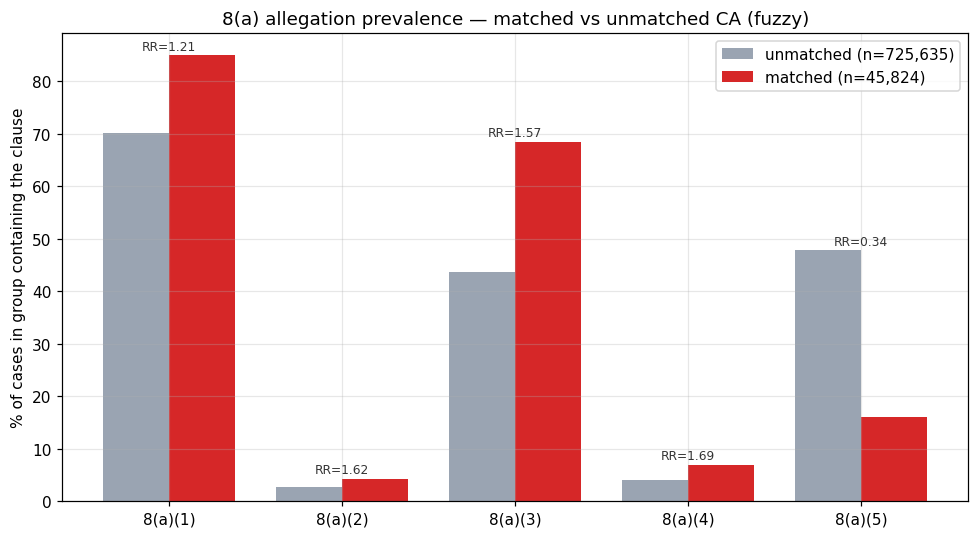

In [6]:
# Grouped bar: clause prevalence, matched vs unmatched
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(CLAUSES)); w = 0.38
ax.bar(x - w/2, tbl_all["unmatched_%"], w, label=f"unmatched (n={n_all.get(False,0):,})", color="#9aa4b2")
ax.bar(x + w/2, tbl_all["matched_%"],   w, label=f"matched (n={n_all.get(True,0):,})",   color="#d62728")
ax.set_xticks(x); ax.set_xticklabels([CLAUSE_LABEL[c] for c in CLAUSES])
ax.set_ylabel("% of cases in group containing the clause")
ax.set_title(f"8(a) allegation prevalence — matched vs unmatched CA ({PRIMARY})")
for i, c in enumerate(CLAUSES):
    rr = tbl_all.loc[i, "risk_ratio"]
    ax.annotate(f"RR={rr}", (i, max(tbl_all.loc[i, "matched_%"], tbl_all.loc[i, "unmatched_%"]) + 1),
                ha="center", fontsize=8, color="#333")
ax.legend()
plt.tight_layout(); plt.show()


## 5. Same comparison, eligible cases only

Restricting to cases that *could* match removes the data-quality cases from the unmatched group, so any remaining difference is about the **nature of the charge**, not missing address fields.

In [7]:
tbl_elig, n_elig = prevalence_table(ca[ca["eligible"]])
print("Eligible-only group sizes:", n_elig.to_dict())
display(tbl_elig)


Eligible-only group sizes: {False: 708229, True: 45824}


,clause,matched_%,unmatched_%,diff_pp,risk_ratio
0,8(a)(1),84.9,70.0,14.8,1.21
1,8(a)(2),4.3,2.6,1.7,1.64
2,8(a)(3),68.5,43.5,25.1,1.58
3,8(a)(4),7.0,4.1,2.9,1.70
4,8(a)(5),16.1,47.8,-31.7,0.34


## 6. How many clauses per charge, and the refusal-to-bargain signal

Two focused views: (a) the number of distinct 8(a) clauses per case, and (b) the share of cases that involve **8(a)(5)** at all vs. **8(a)(3)** at all — the two clauses our hypothesis says should move in opposite directions between matched and unmatched.

In [8]:
# (a) clause-count distribution
cnt = (ca.groupby("matched")["n_clauses"]
       .value_counts(normalize=True).mul(100).rename("pct").reset_index())
pivot = cnt.pivot(index="n_clauses", columns="matched", values="pct").fillna(0).round(1)
pivot.columns = ["unmatched_%" if c is False else "matched_%" for c in pivot.columns]
print("Distribution of # of 8(a) clauses per CA case (%):")
display(pivot)

# (b) headline clause signals
def share(df, col): return 100 * df[col].mean()
for grp, sub in [("matched", ca[ca["matched"]]), ("unmatched", ca[~ca["matched"]])]:
    print(f"\n{grp} (n={len(sub):,}):")
    print(f"  involves 8(a)(3) (discrimination): {share(sub, '8(a)(3)'):.1f}%")
    print(f"  involves 8(a)(5) (refuse-bargain): {share(sub, '8(a)(5)'):.1f}%")
    only5 = ((sub['8(a)(5)'] == 1) & (sub['n_clauses'] == 1)).mean() * 100
    print(f"  pure 8(a)(5) only:                 {only5:.1f}%")


Distribution of # of 8(a) clauses per CA case (%):


,unmatched_%,matched_%
n_clauses,,
0,0.1,0.1
1,43.3,33.0
2,46.0,54.3
3,9.6,11.4
4,0.9,1.1
5,0.1,0.1



matched (n=45,824):
  involves 8(a)(3) (discrimination): 68.5%
  involves 8(a)(5) (refuse-bargain): 16.1%
  pure 8(a)(5) only:                 3.0%

unmatched (n=725,635):
  involves 8(a)(3) (discrimination): 43.6%
  involves 8(a)(5) (refuse-bargain): 47.8%
  pure 8(a)(5) only:                 18.1%


## 7. Save summary and takeaways

In [9]:
out = Path("allegation_prevalence_matched_vs_unmatched.csv")
parts = []
for label, df in [("all_CA", ca), ("eligible_CA", ca[ca["eligible"]])]:
    for method in METHODS:
        tmp = ca if label == "all_CA" else ca[ca["eligible"]]
        t, n = prevalence_table(tmp, group_col=f"matched_{method}")
        t.insert(0, "method", method); t.insert(0, "population", label)
        parts.append(t)
summary = pd.concat(parts, ignore_index=True)
summary.to_csv(out, index=False)
print("Saved", out.resolve())
display(summary)


Saved C:\Users\PsyLab-9221\Documents\NLRB_project\nlrb-matching-cases\allegation_analysis\allegation_prevalence_matched_vs_unmatched.csv


,population,method,clause,matched_%,unmatched_%,diff_pp,risk_ratio
0,all_CA,fuzzy,8(a)(1),84.9,70.2,14.7,1.21
1,all_CA,fuzzy,8(a)(2),4.3,2.7,1.7,1.62
2,all_CA,fuzzy,8(a)(3),68.5,43.6,25.0,1.57
3,all_CA,fuzzy,8(a)(4),7.0,4.1,2.8,1.69
4,all_CA,fuzzy,8(a)(5),16.1,47.8,-31.7,0.34
5,all_CA,cluster,8(a)(1),84.3,70.0,14.2,1.20
6,all_CA,cluster,8(a)(2),4.3,2.7,1.6,1.60
7,all_CA,cluster,8(a)(3),68.0,43.3,24.7,1.57
8,all_CA,cluster,8(a)(4),7.1,4.1,3.0,1.74
9,all_CA,cluster,8(a)(5),17.0,48.1,-31.1,0.35


### Reading guide

- **Risk ratio (RR)** is the headline: RR > 1 means a clause is *more* common among matched cases,
  RR < 1 means *less* common. Compare the §4 (all CA) and §5 (eligible-only) tables — if the pattern
  holds in both, it isn't driven by missing-address cases.
- The hypothesis to check: **8(a)(3)** (and to a lesser extent 8(a)(1)) over-represented among matched,
  **8(a)(5)** under-represented. If so, it supports that the low CA match rate is substantive — a large
  share of unmatched charges are existing-union disputes (refusal to bargain) with no concurrent
  organizing petition to match.
- Both matching methods are in the saved CSV so you can confirm the allegation pattern is a property
  of the cases, not of the matcher.